1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Style global
sns.set_theme(style="whitegrid", palette="Greens_d")
plt.rcParams.update({
    "figure.facecolor": "#F8FAF9",
    "axes.facecolor":   "#F8FAF9",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
})

Cellule 2 — Chargement du dataset

In [5]:
df_raw = pd.read_csv("online_retail.csv", encoding="latin-1")
df = df_raw.copy()

print(f"Shape : {df.shape}")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nMissing values :\n{df.isnull().sum()}")
df.head()

Shape : (541909, 8)

Types :
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing values :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Cellule 3 — Nettoyage & feature engineering

In [10]:
# Colonnes temporelles
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Year"]        = df["InvoiceDate"].dt.year
df["Month"]       = df["InvoiceDate"].dt.month
df["MonthName"]   = df["InvoiceDate"].dt.strftime("%b")
df["DayOfWeek"]   = df["InvoiceDate"].dt.dayofweek
df["DayName"]     = df["InvoiceDate"].dt.strftime("%a")
df["Hour"]        = df["InvoiceDate"].dt.hour

# Indicateurs
df["IsReturn"] = df["InvoiceNo"].astype(str).str.startswith("C") #si invoiceno commence par c => facture de return
df["Revenue"]  = df["Quantity"] * df["UnitPrice"]

# Dataset propre (hors retours, prix > 0, quantité > 0)
df_clean = df[
    (~df["IsReturn"]) &
    (df["UnitPrice"] > 0) &
    (df["Quantity"] > 0)
].copy()

print(f"Lignes brutes     : {len(df):,}")
print(f"Lignes propres    : {len(df_clean):,}")
print(f"Retours détectés  : {df['IsReturn'].sum():,} ({df['IsReturn'].mean()*100:.1f}%)")
print(f"Clients uniques   : {df_clean['CustomerID'].nunique():,}")
print(f"Pays uniques      : {df_clean['Country'].nunique()}")

Lignes brutes     : 541,909
Lignes propres    : 530,104
Retours détectés  : 9,288 (1.7%)
Clients uniques   : 4,338
Pays uniques      : 38


 PARTIE 1 — DISTRIBUTIONS

Cellule 4 — Distribution des prix unitaires

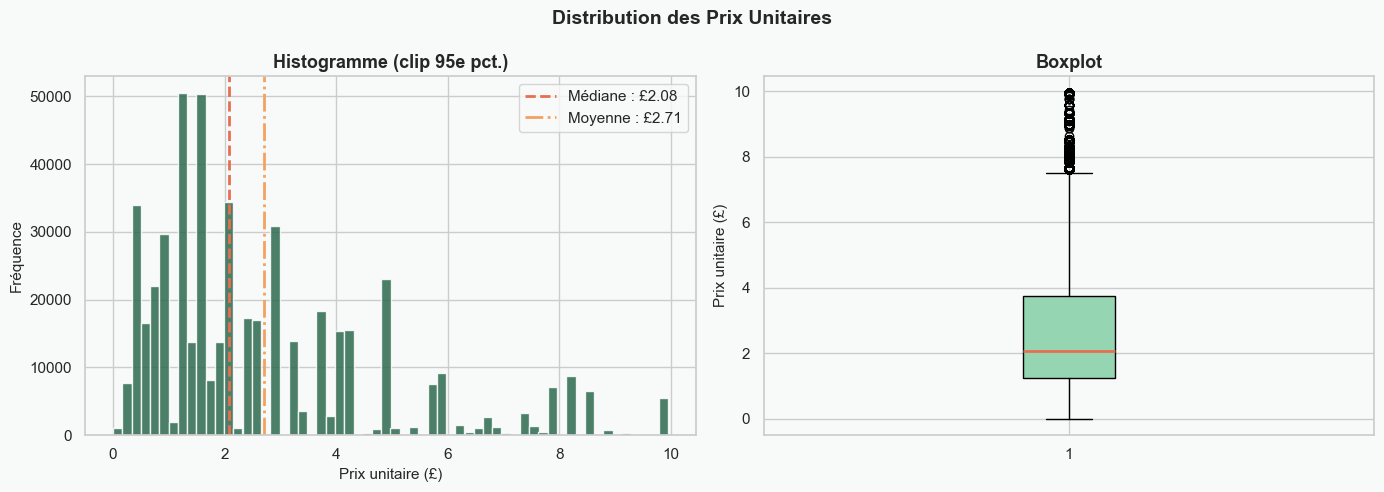


Statistiques prix :
count    505567.00
mean          2.71
std           2.17
min           0.00
25%           1.25
50%           2.08
75%           3.75
max           9.95
Name: UnitPrice, dtype: float64
Skewness  : 1.35
Kurtosis  : 1.31


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des Prix Unitaires", fontsize=14, fontweight="bold")

price_95 = df_clean["UnitPrice"].quantile(0.95) #calcule le 95e percentile= 95% des prix sont en dessous de cette valeur.
data_p   = df_clean[df_clean["UnitPrice"] <= price_95]["UnitPrice"]

# Histogramme
axes[0].hist(data_p, bins=60, color="#2D6A4F", edgecolor="white", alpha=0.85)
axes[0].axvline(data_p.median(), color="#E76F51", lw=2, ls="--",
                label=f"Médiane : £{data_p.median():.2f}")
axes[0].axvline(data_p.mean(), color="#F4A261", lw=2, ls="-.",
                label=f"Moyenne : £{data_p.mean():.2f}")
axes[0].set_xlabel("Prix unitaire (£)")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Histogramme (clip 95e pct.)")
axes[0].legend()

# Boxplot
axes[1].boxplot(data_p, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#95D5B2"),
                medianprops=dict(color="#E76F51", linewidth=2))
axes[1].set_ylabel("Prix unitaire (£)")
axes[1].set_title("Boxplot")

plt.tight_layout()
plt.show()

print(f"\nStatistiques prix :")
print(data_p.describe().round(2))
print(f"Skewness  : {stats.skew(data_p):.2f}") #Skewness = asymétrie
print(f"Kurtosis  : {stats.kurtosis(data_p):.2f}") #Kurtosis = concentration / poids des queues

Cellule 5 — Distribution des quantités

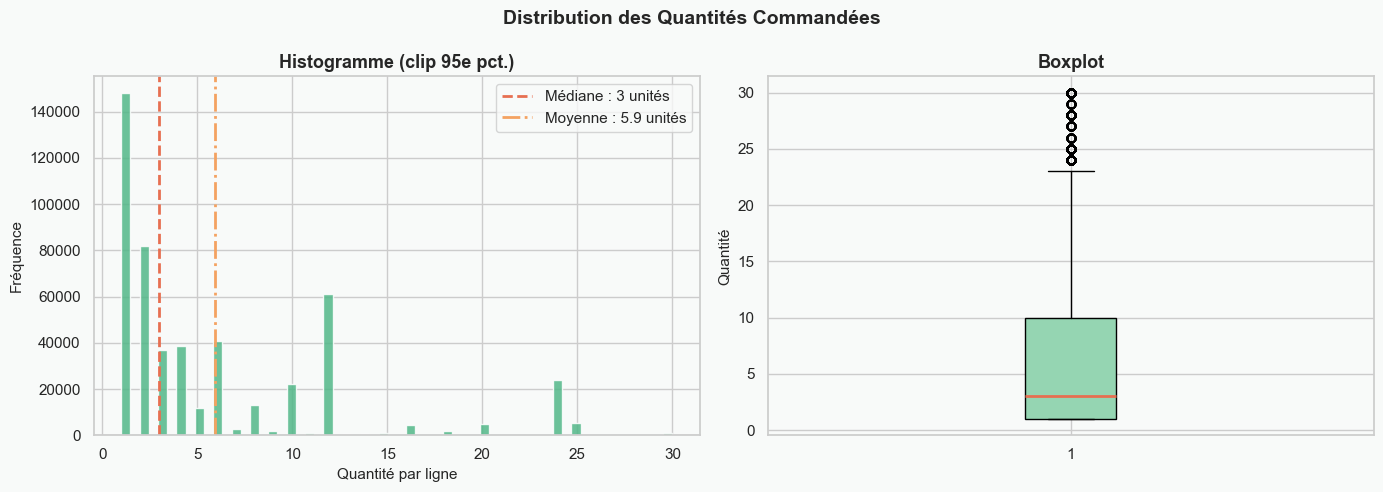


Statistiques quantités :
count    504470.00
mean          5.92
std           6.39
min           1.00
25%           1.00
50%           3.00
75%          10.00
max          30.00
Name: Quantity, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des Quantités Commandées", fontsize=14, fontweight="bold")

qty_95 = df_clean["Quantity"].quantile(0.95)
data_q = df_clean[df_clean["Quantity"] <= qty_95]["Quantity"]

axes[0].hist(data_q, bins=60, color="#52B788", edgecolor="white", alpha=0.85)
axes[0].axvline(data_q.median(), color="#E76F51", lw=2, ls="--",
                label=f"Médiane : {data_q.median():.0f} unités")
axes[0].axvline(data_q.mean(), color="#F4A261", lw=2, ls="-.",
                label=f"Moyenne : {data_q.mean():.1f} unités")
axes[0].set_xlabel("Quantité par ligne")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Histogramme (clip 95e pct.)")
axes[0].legend()

axes[1].boxplot(data_q, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#95D5B2"),
                medianprops=dict(color="#E76F51", linewidth=2))
axes[1].set_ylabel("Quantité")
axes[1].set_title("Boxplot")

plt.tight_layout()
plt.show()

print(f"\nStatistiques quantités :")
print(data_q.describe().round(2))

Cellule 6 — Distribution du CA par ligne

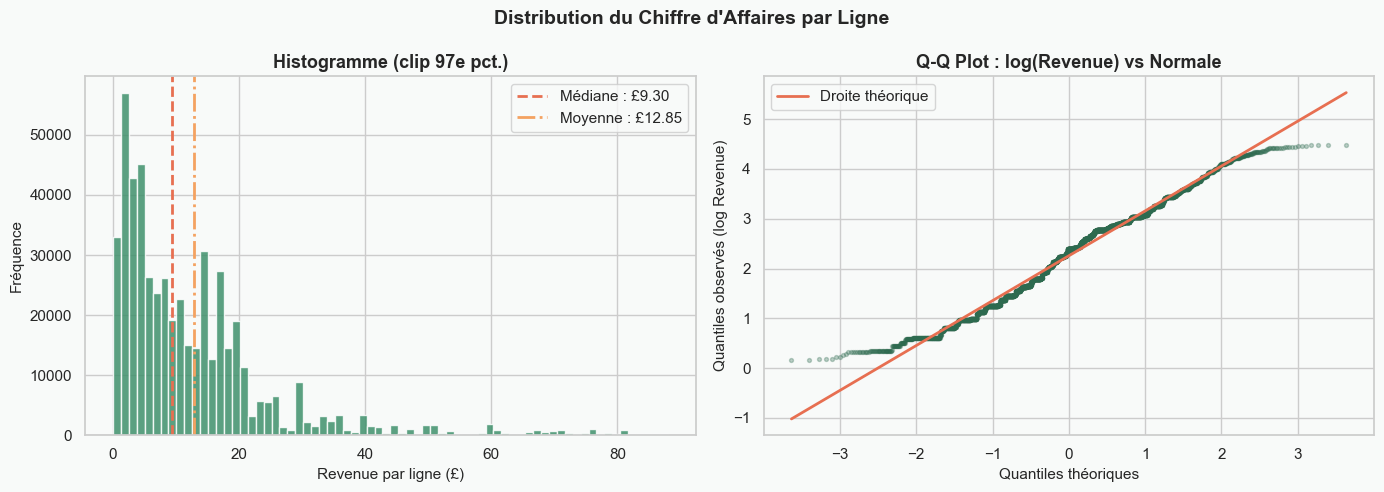

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution du Chiffre d'Affaires par Ligne", fontsize=14, fontweight="bold")

rev_95 = df_clean["Revenue"].quantile(0.97)
data_r = df_clean[df_clean["Revenue"] <= rev_95]["Revenue"]

axes[0].hist(data_r, bins=70, color="#40916C", edgecolor="white", alpha=0.85)
axes[0].axvline(data_r.median(), color="#E76F51", lw=2, ls="--",
                label=f"Médiane : £{data_r.median():.2f}")
axes[0].axvline(data_r.mean(), color="#F4A261", lw=2, ls="-.",
                label=f"Moyenne : £{data_r.mean():.2f}")
axes[0].set_xlabel("Revenue par ligne (£)")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Histogramme (clip 97e pct.)")
axes[0].legend()

# Q-Q plot (log du revenue)
sample = data_r.sample(5000, random_state=42)
(osm, osr), (slope, intercept, _) = stats.probplot(np.log1p(sample), dist="norm")
axes[1].scatter(osm, osr, alpha=0.3, s=8, color="#2D6A4F")
line_x = np.array([osm.min(), osm.max()])
axes[1].plot(line_x, slope * line_x + intercept, color="#E76F51", lw=2,
             label="Droite théorique")
axes[1].set_xlabel("Quantiles théoriques")
axes[1].set_ylabel("Quantiles observés (log Revenue)")
axes[1].set_title("Q-Q Plot : log(Revenue) vs Normale")
axes[1].legend()

plt.tight_layout()
plt.show()

Periode de la dataset

In [15]:
print("=" * 45)
print("   PÉRIODE DU DATASET")
print("=" * 45)
print(f"  Début   : {df['InvoiceDate'].min()}")
print(f"  Fin     : {df['InvoiceDate'].max()}")
print(f"  Durée   : {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} jours")
print("=" * 45)

   PÉRIODE DU DATASET
  Début   : 2010-12-01 08:26:00
  Fin     : 2011-12-09 12:50:00
  Durée   : 373 jours


PARTIE 2 — SAISONNALITÉ

Cellule 7 — CA mensuel

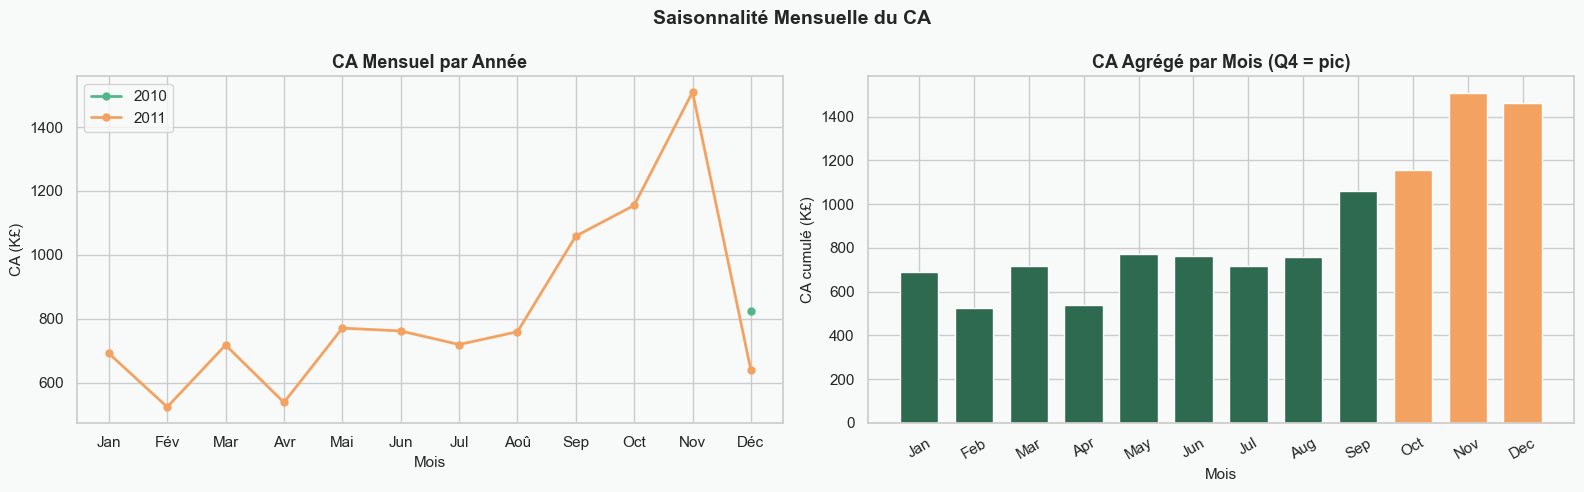

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Saisonnalité Mensuelle du CA", fontsize=14, fontweight="bold")

# Évolution mensuelle par année
monthly = df_clean.groupby(["Year", "Month"])["Revenue"].sum().reset_index()
colors_yr = {2009: "#2D6A4F", 2010: "#52B788", 2011: "#F4A261"}
for year, grp in monthly.groupby("Year"):
    axes[0].plot(grp["Month"], grp["Revenue"] / 1e3,
                 marker="o", ms=5, lw=2,
                 color=colors_yr[year], label=str(year))
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("CA (K£)")
axes[0].set_title("CA Mensuel par Année")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun",
                          "Jul","Aoû","Sep","Oct","Nov","Déc"])
axes[0].legend()

# CA agrégé par mois (toutes années)
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
month_agg = df_clean.groupby("MonthName")["Revenue"].sum()
month_agg = month_agg.reindex(month_order)
bar_colors = ["#F4A261" if m in ["Oct","Nov","Dec"] else "#2D6A4F"
              for m in month_order]
axes[1].bar(month_order, month_agg.values / 1e3,
            color=bar_colors, edgecolor="white", width=0.7)
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("CA cumulé (K£)")
axes[1].set_title("CA Agrégé par Mois (Q4 = pic)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Cellule 8 — Saisonnalité horaire & hebdomadaire

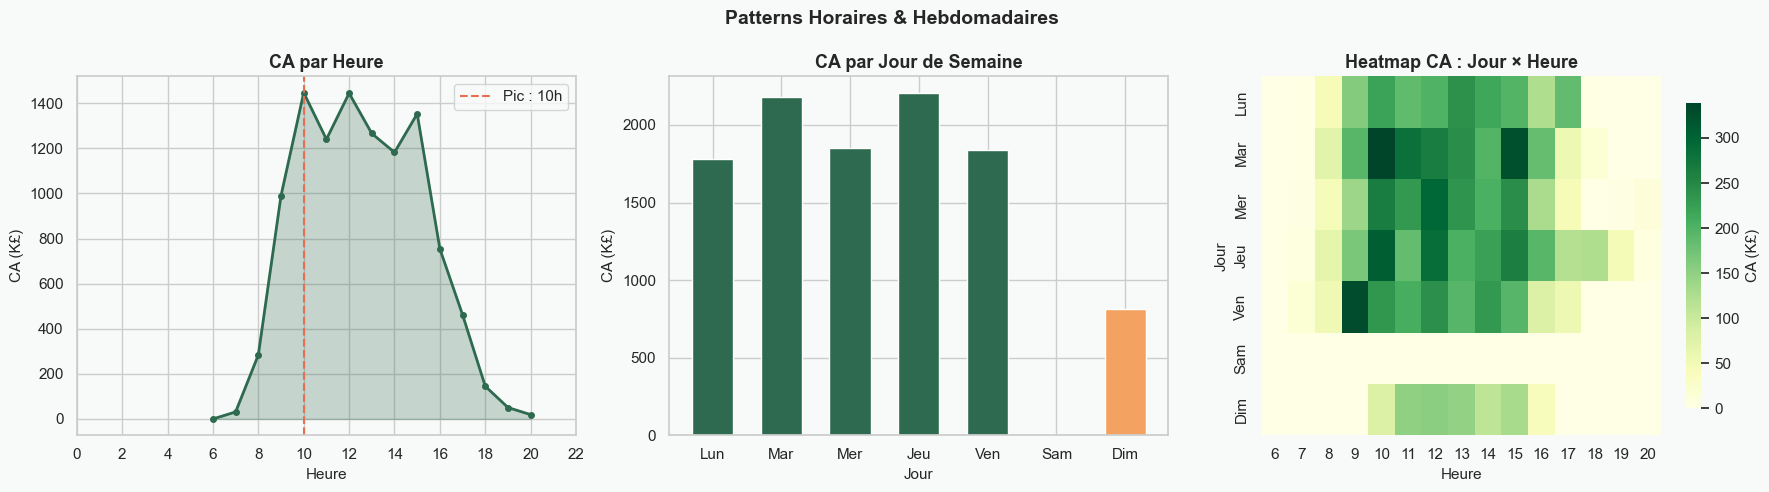

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Patterns Horaires & Hebdomadaires", fontsize=14, fontweight="bold")

day_order  = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
day_labels = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]

# CA par heure
hourly = df_clean.groupby("Hour")["Revenue"].sum()
axes[0].fill_between(hourly.index, hourly.values / 1e3, alpha=0.25, color="#2D6A4F")
axes[0].plot(hourly.index, hourly.values / 1e3, marker="o", ms=4,
             color="#2D6A4F", lw=2)
axes[0].axvline(hourly.idxmax(), color="#E76F51", ls="--", lw=1.5,
                label=f"Pic : {hourly.idxmax()}h")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("CA (K£)")
axes[0].set_title("CA par Heure")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# CA par jour de semaine
df_clean["DayAbbr"] = df_clean["DayOfWeek"].map(
    dict(zip(range(7), day_labels)))
day_rev = df_clean.groupby("DayAbbr")["Revenue"].sum().reindex(day_labels)
bar_c   = ["#F4A261" if d in ["Sam","Dim"] else "#2D6A4F" for d in day_labels]
axes[1].bar(day_labels, day_rev.values / 1e3, color=bar_c, edgecolor="white", width=0.6)
axes[1].set_xlabel("Jour")
axes[1].set_ylabel("CA (K£)")
axes[1].set_title("CA par Jour de Semaine")

# Heatmap Jour × Heure
heatmap_data = df_clean.groupby(["DayOfWeek", "Hour"])["Revenue"].sum().unstack(fill_value=0)

# Réindexer proprement pour avoir les 7 jours même si un jour est manquant
heatmap_data = heatmap_data.reindex(range(7), fill_value=0)
heatmap_data.index = day_labels

sns.heatmap(heatmap_data / 1e3, ax=axes[2], cmap="YlGn",
            cbar_kws={"label": "CA (K£)", "shrink": 0.85})
axes[2].set_xlabel("Heure")
axes[2].set_ylabel("Jour")
axes[2].set_title("Heatmap CA : Jour × Heure")

plt.tight_layout()
plt.show()

PARTIE 3 — B2B vs B2C

Cellule 9 — Identifier les clients B2B

In [21]:
# Heuristique B2B : quantité médiane par client >= 50 unités
customer_median_qty = df_clean.groupby("CustomerID")["Quantity"].median()
b2b_customers       = customer_median_qty[customer_median_qty >= 50].index

df_clean["IsB2B"]   = df_clean["CustomerID"].isin(b2b_customers)

df_b2b = df_clean[df_clean["IsB2B"]].copy()
df_b2c = df_clean[~df_clean["IsB2B"]].copy()

print(f"Lignes B2B : {len(df_b2b):,} ({len(df_b2b)/len(df_clean)*100:.1f}%)")
print(f"Lignes B2C : {len(df_b2c):,} ({len(df_b2c)/len(df_clean)*100:.1f}%)")
print(f"\nClients B2B : {df_b2b['CustomerID'].nunique():,}")
print(f"Clients B2C : {df_b2c['CustomerID'].nunique():,}")

Lignes B2B : 7,396 (1.4%)
Lignes B2C : 522,708 (98.6%)

Clients B2B : 145
Clients B2C : 4,193


Cellule 10 — Comparaison B2B vs B2C

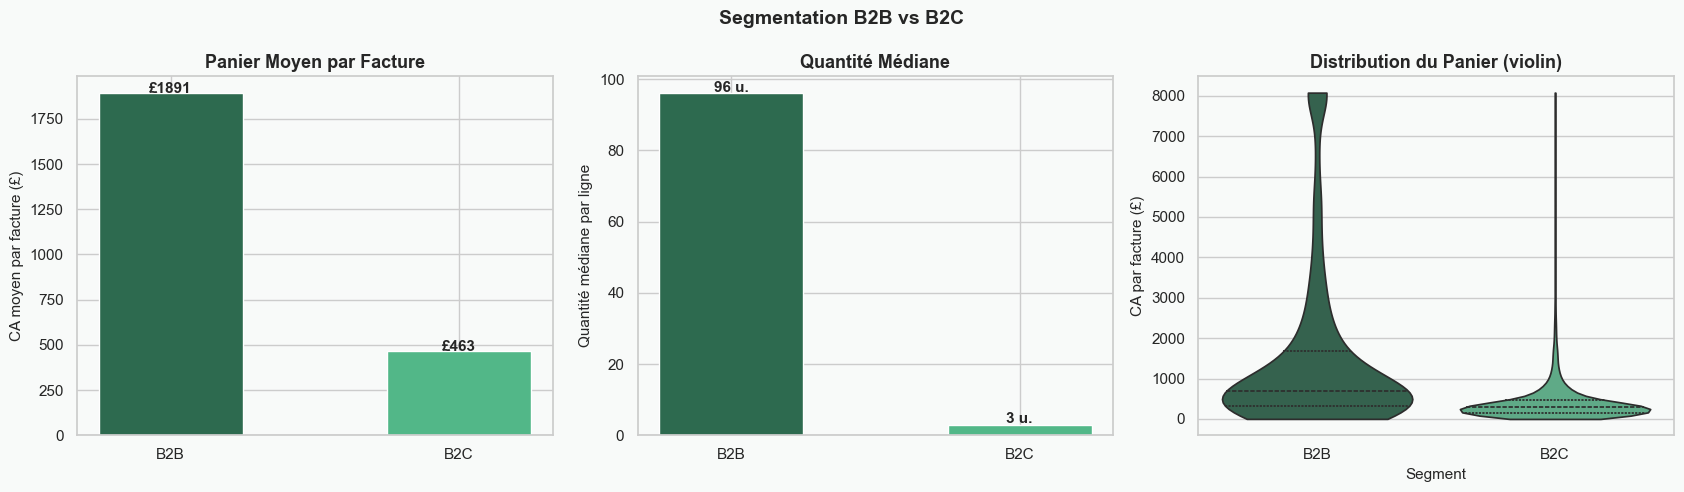

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Segmentation B2B vs B2C", fontsize=14, fontweight="bold")

labels = ["B2B", "B2C"]
colors = ["#2D6A4F", "#52B788"]

# Panier moyen par facture
inv_b2b = df_b2b.groupby("InvoiceNo")["Revenue"].sum()
inv_b2c = df_b2c.groupby("InvoiceNo")["Revenue"].sum()
means   = [inv_b2b.mean(), inv_b2c.mean()]
bars    = axes[0].bar(labels, means, color=colors, edgecolor="white", width=0.5)
for bar, v in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 5,
                 f"£{v:.0f}", ha="center", fontweight="bold", fontsize=11)
axes[0].set_ylabel("CA moyen par facture (£)")
axes[0].set_title("Panier Moyen par Facture")

# Quantité médiane
med_qty = [df_b2b["Quantity"].median(), df_b2c["Quantity"].median()]
bars2   = axes[1].bar(labels, med_qty, color=colors, edgecolor="white", width=0.5)
for bar, v in zip(bars2, med_qty):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f"{v:.0f} u.", ha="center", fontweight="bold", fontsize=11)
axes[1].set_ylabel("Quantité médiane par ligne")
axes[1].set_title("Quantité Médiane")

# Distribution du panier (violin)
clip_val  = max(inv_b2b.quantile(0.95), inv_b2c.quantile(0.95))
plot_data = pd.DataFrame({
    "CA":      pd.concat([inv_b2b.clip(upper=clip_val),
                          inv_b2c.clip(upper=clip_val)]),
    "Segment": ["B2B"] * len(inv_b2b) + ["B2C"] * len(inv_b2c)
})
sns.violinplot(data=plot_data, x="Segment", y="CA", ax=axes[2],
               palette={"B2B": "#2D6A4F", "B2C": "#52B788"},
               inner="quartile", cut=0)
axes[2].set_ylabel("CA par facture (£)")
axes[2].set_title("Distribution du Panier (violin)")

plt.tight_layout()
plt.show()

Cellule 11 — Fréquence & fidélité B2B vs B2C

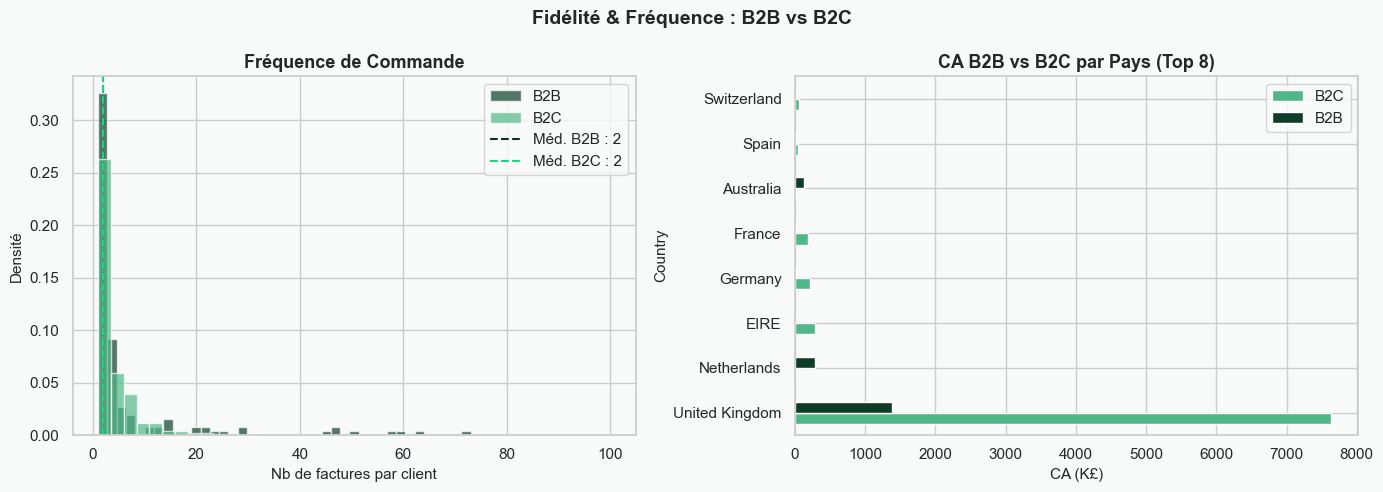

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fidélité & Fréquence : B2B vs B2C", fontsize=14, fontweight="bold")

freq_b2b = df_b2b.groupby("CustomerID")["InvoiceNo"].nunique().clip(upper=100)
freq_b2c = df_b2c.groupby("CustomerID")["InvoiceNo"].nunique().clip(upper=100)

# Histogramme superposé
axes[0].hist(freq_b2b, bins=40, alpha=0.7, color="#0F412B", label="B2B", density=True)
axes[0].hist(freq_b2c, bins=40, alpha=0.7, color="#52B788", label="B2C", density=True)
axes[0].axvline(freq_b2b.median(), color="#0A311F", ls="--", lw=1.5,
                label=f"Méd. B2B : {freq_b2b.median():.0f}")
axes[0].axvline(freq_b2c.median(), color="#17D680", ls="--", lw=1.5,
                label=f"Méd. B2C : {freq_b2c.median():.0f}")
axes[0].set_xlabel("Nb de factures par client")
axes[0].set_ylabel("Densité")
axes[0].set_title("Fréquence de Commande")
axes[0].legend()

# CA total B2B vs B2C par pays (top 8)
top_pays = df_clean.groupby(["Country","IsB2B"])["Revenue"].sum().unstack(fill_value=0)
top_pays.columns = ["B2C","B2B"]
top_pays = top_pays.assign(Total=top_pays.sum(axis=1)).nlargest(8,"Total").drop("Total",axis=1)
top_pays[["B2C","B2B"]].div(1e3).plot(kind="barh", ax=axes[1],
                                        color=["#52B788","#0E3C27"],
                                        edgecolor="white")
axes[1].set_xlabel("CA (K£)")
axes[1].set_title("CA B2B vs B2C par Pays (Top 8)")
axes[1].legend(["B2C","B2B"])

plt.tight_layout()
plt.show()

 PARTIE 4 — LONGUE TRAÎNE

Cellule 12 — Courbe de Pareto clients

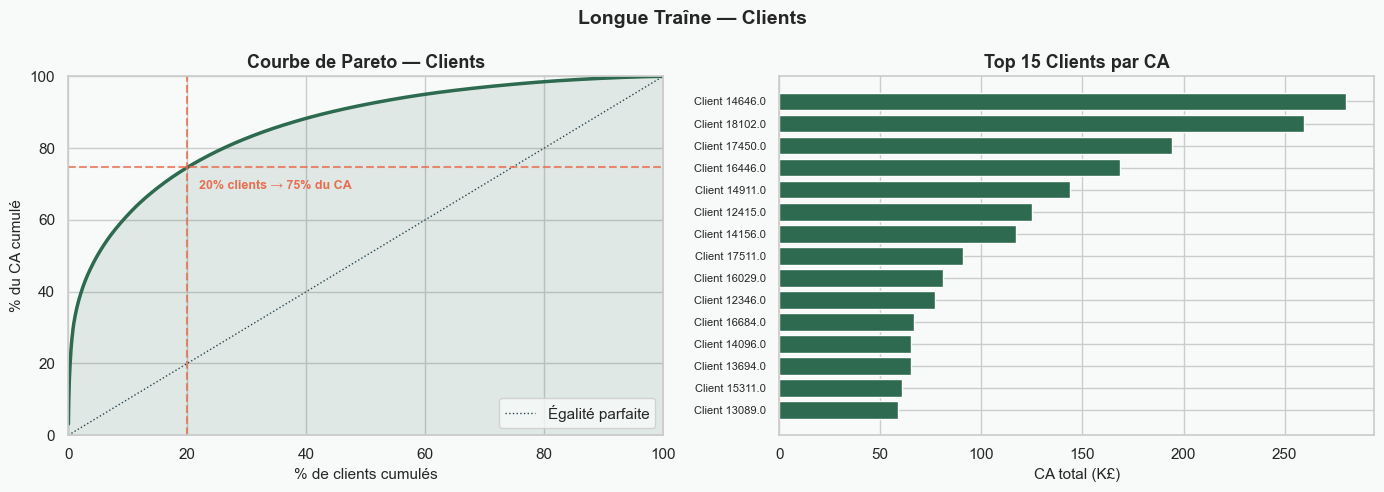

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Longue Traîne — Clients", fontsize=14, fontweight="bold")

cust_rev = df_clean.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
cust_rev_pct   = np.cumsum(cust_rev.values) / cust_rev.sum() * 100
cust_count_pct = np.arange(1, len(cust_rev) + 1) / len(cust_rev) * 100

# Pareto
axes[0].plot(cust_count_pct, cust_rev_pct, color="#2D6A4F", lw=2.5)
axes[0].fill_between(cust_count_pct, cust_rev_pct, alpha=0.12, color="#2D6A4F")
axes[0].plot([0,100],[0,100], ":", color="#264653", lw=1, label="Égalité parfaite")
# Annotation 20/80
idx20 = np.searchsorted(cust_count_pct, 20)
axes[0].axvline(20, color="#E76F51", ls="--", lw=1.5, alpha=0.8)
axes[0].axhline(cust_rev_pct[idx20], color="#E76F51", ls="--", lw=1.5, alpha=0.8)
axes[0].text(22, cust_rev_pct[idx20] - 6,
             f"20% clients → {cust_rev_pct[idx20]:.0f}% du CA",
             fontsize=9, color="#E76F51", fontweight="bold")
axes[0].set_xlabel("% de clients cumulés")
axes[0].set_ylabel("% du CA cumulé")
axes[0].set_title("Courbe de Pareto — Clients")
axes[0].set_xlim(0,100); axes[0].set_ylim(0,100)
axes[0].legend()

# Top 15 clients
top15 = cust_rev.head(15)
axes[1].barh(range(15), top15.values[::-1] / 1e3,
             color="#2D6A4F", edgecolor="white")
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([f"Client {c}" for c in top15.index[::-1]], fontsize=8)
axes[1].set_xlabel("CA total (K£)")
axes[1].set_title("Top 15 Clients par CA")

plt.tight_layout()
plt.show()

Cellule 13 — Courbe de Lorenz + Gini

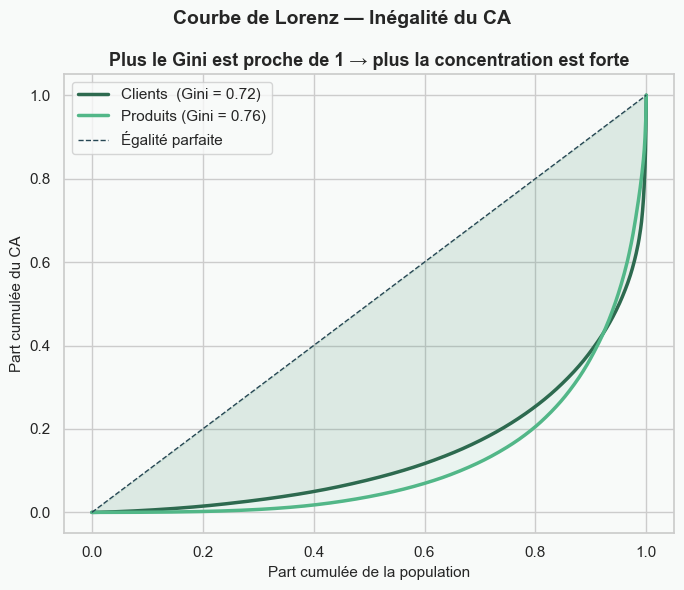

Gini clients  : 0.715  → Forte concentration
Gini produits : 0.763  → Forte concentration


In [31]:
def lorenz_curve(values):
    v  = np.sort(values)
    cs = np.cumsum(v)
    x  = np.linspace(0, 1, len(v))
    y  = cs / cs[-1]
    return x, y

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle("Courbe de Lorenz — Inégalité du CA", fontsize=14, fontweight="bold")

prod_rev = df_clean.groupby("StockCode")["Revenue"].sum()

x_c, y_c = lorenz_curve(cust_rev.values)
x_p, y_p = lorenz_curve(prod_rev.values)

gini_c = 1 - 2 * np.trapezoid(y_c, x_c)
gini_p = 1 - 2 * np.trapezoid(y_p, x_p)

ax.plot(x_c, y_c, color="#2D6A4F", lw=2.5, label=f"Clients  (Gini = {gini_c:.2f})")
ax.plot(x_p, y_p, color="#52B788", lw=2.5, label=f"Produits (Gini = {gini_p:.2f})")
ax.plot([0,1],[0,1], "--", color="#264653", lw=1, label="Égalité parfaite")
ax.fill_between(x_c, y_c, np.linspace(0,1,len(x_c)), alpha=0.08, color="#2D6A4F")
ax.fill_between(x_p, y_p, np.linspace(0,1,len(x_p)), alpha=0.08, color="#52B788")

ax.set_xlabel("Part cumulée de la population")
ax.set_ylabel("Part cumulée du CA")
ax.set_title("Plus le Gini est proche de 1 → plus la concentration est forte")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Gini clients  : {gini_c:.3f}  → {'Forte' if gini_c > 0.6 else 'Modérée'} concentration")
print(f"Gini produits : {gini_p:.3f}  → {'Forte' if gini_p > 0.6 else 'Modérée'} concentration")

Cellule 14 — Fréquence d'achat par client

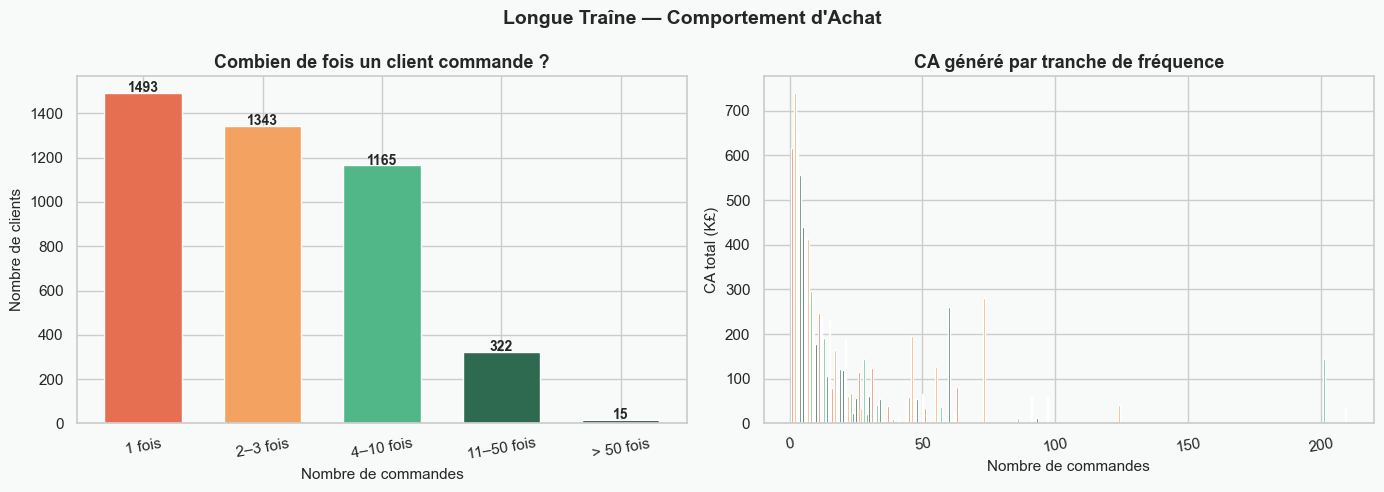

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Longue Traîne — Comportement d'Achat", fontsize=14, fontweight="bold")

# Nb de factures par client
nb_invoices = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()
buckets = pd.cut(nb_invoices,
                 bins=[0, 1, 3, 10, 50, np.inf],
                 labels=["1 fois", "2–3 fois", "4–10 fois", "11–50 fois", "> 50 fois"])
bucket_counts = buckets.value_counts().sort_index()

axes[0].bar(bucket_counts.index, bucket_counts.values,
            color=["#E76F51","#F4A261","#52B788","#2D6A4F","#1B4332"],
            edgecolor="white", width=0.65)
for i, v in enumerate(bucket_counts.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Nombre de commandes")
axes[0].set_ylabel("Nombre de clients")
axes[0].set_title("Combien de fois un client commande ?")
axes[0].tick_params(axis="x", rotation=10)

# CA par tranche de fréquence
rev_per_bucket = df_clean[df_clean["CustomerID"].isin(nb_invoices.index)].copy()
rev_per_bucket["Bucket"] = nb_invoices[rev_per_bucket["CustomerID"].values].values
bucket_rev = rev_per_bucket.groupby("Bucket")["Revenue"].sum() / 1e3

axes[1].bar(bucket_rev.index, bucket_rev.values,
            color=["#E76F51","#F4A261","#52B788","#2D6A4F","#1B4332"],
            edgecolor="white", width=0.65)
axes[1].set_xlabel("Nombre de commandes")
axes[1].set_ylabel("CA total (K£)")
axes[1].set_title("CA généré par tranche de fréquence")
axes[1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()

Cellule 15 — Synthèse finale

In [ ]:
uk_pct     = df_clean[df_clean["Country"]=="United Kingdom"]["Revenue"].sum() / df_clean["Revenue"].sum() * 100
b2b_rev    = df_clean[df_clean["IsB2B"]]["Revenue"].sum() / df_clean["Revenue"].sum() * 100
top1_c_pct = cust_rev.iloc[0] / cust_rev.sum() * 100
peak_hour  = df_clean.groupby("Hour")["Revenue"].sum().idxmax()
peak_month = df_clean.groupby("MonthName")["Revenue"].sum().idxmax()

print("=" * 50)
print("   SYNTHÈSE PHASE 2 — Online Retail")
print("=" * 50)
print(f"  Transactions nettes     : {len(df_clean):,}")
print(f"  Clients uniques         : {df_clean['CustomerID'].nunique():,}")
print(f"  SKUs uniques            : {df_clean['StockCode'].nunique():,}") #stockCode
print(f"  Pays couverts           : {df_clean['Country'].nunique()}")
print(f"  CA total                : £{df_clean['Revenue'].sum()/1e6:.2f}M")
print(f"  Part UK dans le CA      : {uk_pct:.1f}%")
print(f"  Part B2B dans le CA     : {b2b_rev:.1f}%")
print(f"  Gini clients            : {gini_c:.3f}")
print(f"  Gini produits           : {gini_p:.3f}")
print(f"  Top client (part CA)    : {top1_c_pct:.1f}%")
print(f"  Pic horaire             : {peak_hour}h")
print(f"  Pic mensuel             : {peak_month}")
print(f"  Panier moyen B2B        : £{inv_b2b.mean():.0f}")
print(f"  Panier moyen B2C        : £{inv_b2c.mean():.0f}")
print("=" * 50)

   SYNTHÈSE PHASE 2 — Online Retail
  Transactions nettes     : 530,104
  Clients uniques         : 4,338
  SKUs uniques            : 3,922
  Pays couverts           : 38
  CA total                : £10.67M
  Part UK dans le CA      : 84.6%
  Part B2B dans le CA     : 17.6%
  Gini clients            : 0.715
  Gini produits           : 0.763
  Top client (part CA)    : 3.1%
  Pic horaire             : 10h
  Pic mensuel             : Nov
  Panier moyen B2B        : £1891
  Panier moyen B2C        : £463


Nb clients par pays

                Pays  Nb Clients
      United Kingdom        3920
             Germany          94
              France          87
               Spain          30
             Belgium          25
         Switzerland          21
            Portugal          19
               Italy          14
             Finland          12
             Austria          11
              Norway          10
     Channel Islands           9
         Netherlands           9
           Australia           9
             Denmark           9
              Cyprus           8
               Japan           8
              Sweden           8
              Poland           6
         Unspecified           4
              Canada           4
                 USA           4
              Greece           4
              Israel           3
                EIRE           3
             Bahrain           2
               Malta           2
United Arab Emirates           2
              Brazil           1
      Czec

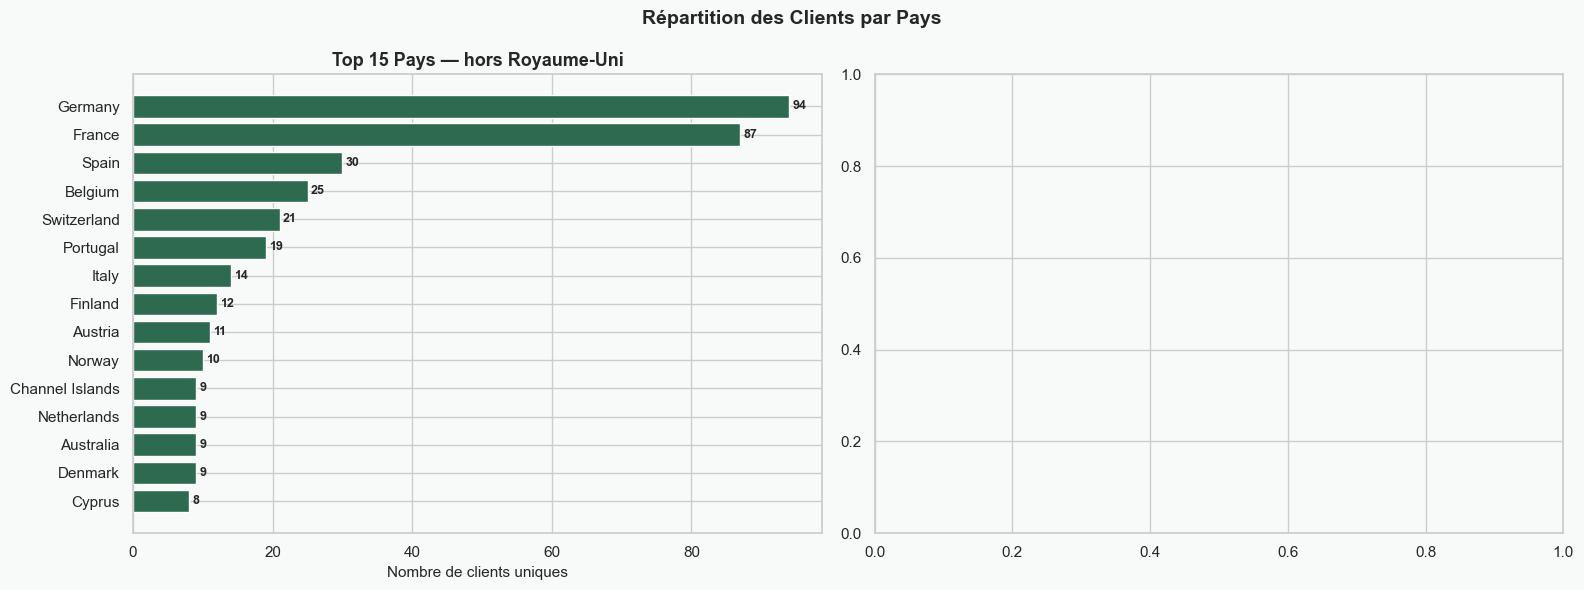

In [40]:
# Nombre de clients uniques par pays
clients_par_pays = (df_clean.groupby("Country")["CustomerID"]
                    .nunique()
                    .sort_values(ascending=False)
                    .reset_index())
clients_par_pays.columns = ["Pays", "Nb Clients"]

print(clients_par_pays.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Répartition des Clients par Pays", fontsize=14, fontweight="bold")

# Tous les pays (hors UK pour mieux voir les autres)
sans_uk = clients_par_pays[clients_par_pays["Pays"] != "United Kingdom"]

# Barplot top 15 sans UK
axes[0].barh(sans_uk.head(15)["Pays"][::-1],
             sans_uk.head(15)["Nb Clients"][::-1],
             color="#2D6A4F", edgecolor="white")
for i, v in enumerate(sans_uk.head(15)["Nb Clients"][::-1]):
    axes[0].text(v + 0.5, i, str(v), va="center", fontsize=9, fontweight="bold")
axes[0].set_xlabel("Nombre de clients uniques")
axes[0].set_title("Top 15 Pays — hors Royaume-Uni")

plt.tight_layout()
plt.show()